# NEET Analysis in Indonesia 2017–2025

## Project Overview

This notebook presents the data analysis workflow used to examine factors associated with the **Not in Employment, Education, or Training (NEET)** rate across 34 provinces in Indonesia during 2017–2025.

The analysis includes exploratory data analysis, preprocessing, panel-data model comparison, interaction effects, and clustered-robust standard errors at the provincial level.

> **Data source:** Badan Pusat Statistik (BPS)

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- SciPy
- Linearmodels

### Analysis Workflow
1. Data loading and inspection
2. Exploratory Data Analysis
3. Data transformation
4. Multicollinearity assessment
5. Panel-data model estimation
6. Model comparison
7. Diagnostic tests
8. Clustered-robust estimation
9. Interaction effects
10. Final model evaluation

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
!pip install linearmodels
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.9 MB/s eta 0:00:00


## 2. Load Dataset

In [3]:
# Update this path when running the notebook locally.
df = pd.read_excel("2017-2025.xlsx")

df.head()

,Provinsi,Tahun,Y,X1,X2,X3,X4,X5,X6,X8,X9,M1,M2
0,Aceh,2017,22.41,70.60,6.57,63.74,54.20,59.58,9.42,16.89,90,51.78,0.329
1,Aceh,2018,22.77,71.19,6.34,64.04,59.05,59.44,9.46,15.97,91,62.96,0.325
2,Aceh,2019,23.61,71.90,6.17,63.13,57.75,57.12,9.59,15.32,93,69.01,0.319
3,Aceh,2020,23.60,73.29,6.59,65.10,59.60,61.88,9.71,14.99,91,76.68,0.323
4,Aceh,2021,24.38,73.48,6.30,63.78,61.20,60.69,9.77,15.33,92,83.84,0.324


## 3. Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Provinsi  306 non-null    object 
 1   Tahun     306 non-null    int64  
 2   Y         306 non-null    float64
 3   X1        306 non-null    float64
 4   X2        306 non-null    float64
 5   X3        306 non-null    float64
 6   X4        306 non-null    float64
 7   X5        306 non-null    float64
 8   X6        306 non-null    float64
 9   X8        306 non-null    float64
 10  X9        306 non-null    int64  
 11  M1        306 non-null    float64
 12  M2        306 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 31.2+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tahun,306.0,2021.000000,2.586218,2017.000,2019.0000,2021.000,2023.00000,2025.000
Y,306.0,21.570719,4.503909,5.330,19.5000,21.785,24.01000,35.380
X1,306.0,72.175588,4.076750,59.090,70.1775,72.165,74.04000,85.050
X2,306.0,4.967386,1.685862,1.400,3.7700,4.580,6.04500,10.950
X3,306.0,68.551797,3.565948,60.180,65.8950,68.720,70.31750,79.020
X4,306.0,65.451373,8.554992,35.330,61.0775,66.240,70.35250,84.470
X5,306.0,58.682255,10.230418,28.450,53.1850,60.285,64.48500,84.430
X6,306.0,9.156863,0.859633,6.580,8.5450,9.165,9.73750,11.580
X8,306.0,10.298170,5.298793,3.470,6.2325,8.715,12.98000,27.740
X9,306.0,745.013072,2685.319852,9.000,49.2500,103.000,267.00000,16165.000


In [6]:
# Check missing values
df.isnull().sum()

,0
Provinsi,0
Tahun,0
Y,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X8,0


In [7]:
# Check duplicated observations
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


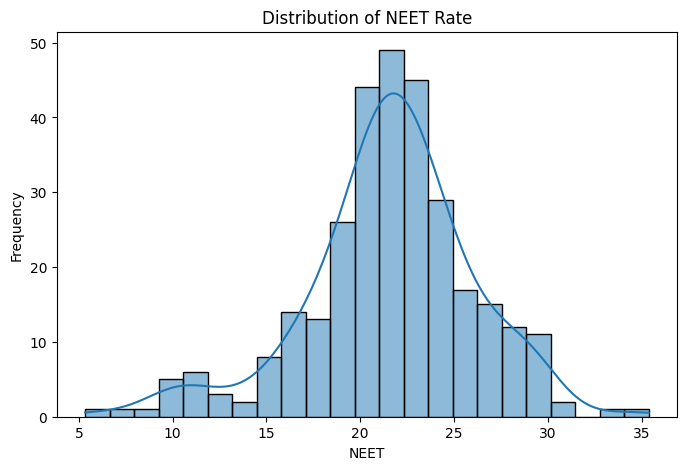

In [8]:
# Distribution of the dependent variable
plt.figure(figsize=(8, 5))
sns.histplot(df["Y"], kde=True)
plt.title("Distribution of NEET Rate")
plt.xlabel("NEET")
plt.ylabel("Frequency")
plt.show()

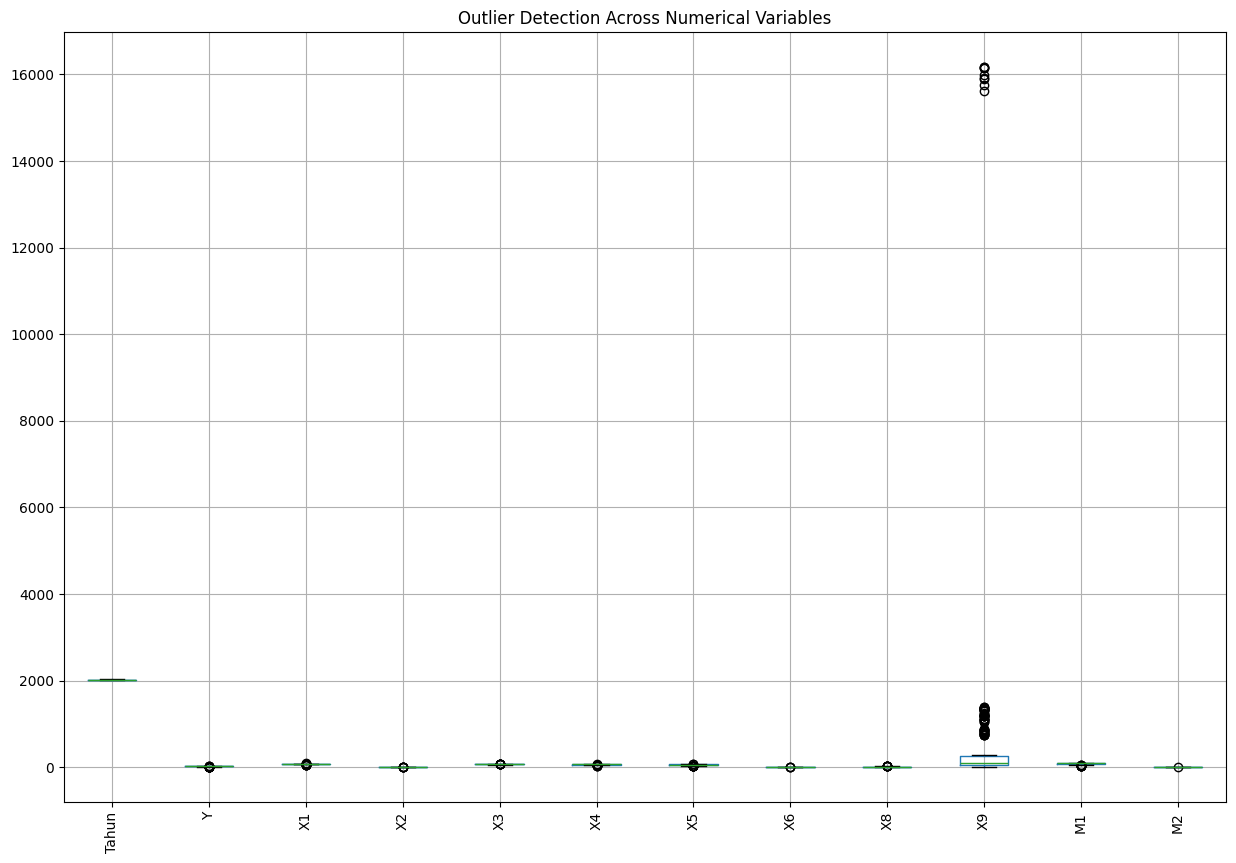

In [9]:
# Boxplots for numerical variables
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns

plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Outlier Detection Across Numerical Variables")
plt.show()

## 4. Variable Transformation

In [10]:
# Natural-log transformation applied to X8 and X9
df["LnX8"] = np.log(df["X8"])
df["LnX9"] = np.log(df["X9"])

df_model = df[
    ["X1", "X2", "X3", "X4", "X5", "X6", "LnX8", "LnX9", "M1", "M2", "Y"]
]

df_model.head()

,X1,X2,X3,X4,X5,X6,LnX8,LnX9,M1,M2,Y
0,70.60,6.57,63.74,54.20,59.58,9.42,2.826722,4.499810,51.78,0.329,22.41
1,71.19,6.34,64.04,59.05,59.44,9.46,2.770712,4.510860,62.96,0.325,22.77
2,71.90,6.17,63.13,57.75,57.12,9.59,2.729159,4.532599,69.01,0.319,23.61
3,73.29,6.59,65.10,59.60,61.88,9.71,2.707383,4.510860,76.68,0.323,23.60
4,73.48,6.30,63.78,61.20,60.69,9.77,2.729812,4.521789,83.84,0.324,24.38


## 5. Multicollinearity Assessment

In [11]:
def calculate_vif(data, variables):
    X = sm.add_constant(data[variables])
    vif = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })
    return vif

initial_variables = [
    "X1", "X2", "X3", "X4", "X5", "X6",
    "LnX8", "LnX9", "M1", "M2"
]

calculate_vif(df, initial_variables)

,Variable,VIF
0,const,1.000000
1,X1,8.222640
2,X2,2.443004
3,X3,1.965788
4,X4,17.430200
5,X5,6.159528
6,X6,4.177538
7,LnX8,3.519272
8,LnX9,4.281890
9,M1,8.369501


### Reduced Predictor Set

The original script also evaluates a reduced predictor set after removing X4 from the model specification.

In [12]:
model_variables = [
    "X1", "X2", "X3", "X5", "X6",
    "LnX8", "LnX9", "M1", "M2"
]

calculate_vif(df, model_variables)

,Variable,VIF
0,const,1.000000
1,X1,8.142969
2,X2,2.322045
3,X3,1.926053
4,X5,3.639840
5,X6,3.601119
6,LnX8,3.153948
7,LnX9,2.889950
8,M1,2.646922
9,M2,1.948451


## 6. Panel Data Setup

In [13]:
df_panel = df.set_index(["Provinsi", "Tahun"])

y = df_panel["Y"]
X = df_panel[model_variables]
X = sm.add_constant(X)

## 7. Panel Data Model Estimation

In [14]:
# Common Effect / Pooled OLS
pooled_model = PooledOLS(y, X)
pooled_res = pooled_model.fit()

print(pooled_res.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:                      Y   R-squared:                        0.7548
Estimator:                  PooledOLS   R-squared (Between):              0.8482
No. Observations:                 306   R-squared (Within):               0.3122
Date:                Mon, Sep 28 2026   R-squared (Overall):              0.7548
Time:                        16:27:49   Log-likelihood                   -679.12
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      101.26
Entities:                          35   P-value                           0.0000
Avg Obs:                       8.7429   Distribution:                   F(9,296)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             101.26
                            

In [15]:
# Fixed Effect Model
fem_model = PanelOLS(y, X, entity_effects=True)
fem_res = fem_model.fit()

print(fem_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                      Y   R-squared:                        0.4622
Estimator:                   PanelOLS   R-squared (Between):             -6.4450
No. Observations:                 306   R-squared (Within):               0.4622
Date:                Mon, Sep 28 2026   R-squared (Overall):             -4.6016
Time:                        16:27:52   Log-likelihood                   -546.50
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      25.014
Entities:                          35   P-value                           0.0000
Avg Obs:                       8.7429   Distribution:                   F(9,262)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             25.014
                            

In [16]:
# Random Effect Model
rem_model = RandomEffects(y, X)
rem_res = rem_model.fit()

print(rem_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                      Y   R-squared:                        0.5509
Estimator:              RandomEffects   R-squared (Between):              0.7701
No. Observations:                 306   R-squared (Within):               0.4124
Date:                Mon, Sep 28 2026   R-squared (Overall):              0.7133
Time:                        16:27:52   Log-likelihood                   -582.20
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      40.346
Entities:                          35   P-value                           0.0000
Avg Obs:                       8.7429   Distribution:                   F(9,296)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             35.221
                            

## 8. Model Comparison

In [17]:
from linearmodels.panel import compare

print("Pooled OLS vs Fixed Effects")
print(compare({"CEM": pooled_res, "FEM": fem_res}))

Pooled OLS vs Fixed Effects
                   Model Comparison                  
                                   CEM            FEM
-----------------------------------------------------
Dep. Variable                        Y              Y
Estimator                    PooledOLS       PanelOLS
No. Observations                   306            306
Cov. Est.                   Unadjusted     Unadjusted
R-squared                       0.7548         0.4622
R-Squared (Within)              0.3122         0.4622
R-Squared (Between)             0.8482        -6.4450
R-Squared (Overall)             0.7548        -4.6016
F-statistic                     101.26         25.014
P-value (F-stat)                0.0000         0.0000
=====================     ============   ============
const                           93.604         51.375
                              (15.034)       (3.1780)
X1                             -0.5500        -0.5260
                             (-6.0621)      (-3.4812)


In [18]:
print("Fixed Effects vs Random Effects")
print(compare({"FEM": fem_res, "REM": rem_res}))

Fixed Effects vs Random Effects
                    Model Comparison                    
                                   FEM               REM
--------------------------------------------------------
Dep. Variable                        Y                 Y
Estimator                     PanelOLS     RandomEffects
No. Observations                   306               306
Cov. Est.                   Unadjusted        Unadjusted
R-squared                       0.4622            0.5509
R-Squared (Within)              0.4622            0.4124
R-Squared (Between)            -6.4450            0.7701
R-Squared (Overall)            -4.6016            0.7133
F-statistic                     25.014            40.346
P-value (F-stat)                0.0000            0.0000
=====================     ============   ===============
const                           51.375            80.153
                              (3.1780)          (10.943)
X1                             -0.5260           -0.5795

## 9. Diagnostic Tests

### Glejser Test

The original analysis applies a Glejser test using the absolute residuals from the FEM specification.

In [19]:
residual = fem_res.resids
abs_resid = np.abs(residual)

glejser_X = sm.add_constant(df_panel[model_variables])
glejser_model = sm.OLS(abs_resid, glejser_X).fit()

print(glejser_model.summary)

<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x7a64a9da9d90>>


### Durbin-Watson

The following reproduces the Durbin-Watson calculation contained in the original script.

In [20]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(fem_res.resids)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.5375974545403057


### Jarque-Bera Test

In [21]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(fem_res.resids)
print("Jarque-Bera statistic:", jb_stat)
print("p-value:", jb_p)

Jarque-Bera statistic: 35.432209889291094
p-value: 2.0229883498217536e-08


## 10. Clustered-Robust Standard Errors

In [22]:
# Province fixed effects using LSDV
dummies = pd.get_dummies(df["Provinsi"], drop_first=True).astype(int)

X_fem = pd.concat(
    [df[model_variables], dummies],
    axis=1
)
X_fem = sm.add_constant(X_fem)

Y_fem = df["Y"]

# Cluster standard errors by province
fem_lsdv_cluster = sm.OLS(Y_fem, X_fem).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["Provinsi"]}
)

print(fem_lsdv_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     6.385
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.93e-05
Time:                        16:28:04   Log-Likelihood:                -546.50
No. Observations:                 306   AIC:                             1181.
Df Residuals:                     262   BIC:                             1345.
Df Model:                          43                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  57.0175    

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 43, but rank is 9
  res = self.wald_test(


## 11. Interaction Effects

All modeled variables used in the interaction specification are mean-centered before constructing interaction terms.

In [23]:
# Mean-centering
center_map = {
    "X1": "X1c",
    "X2": "X2c",
    "X3": "X3c",
    "X5": "X5c",
    "X6": "X6c",
    "LnX8": "X8c",
    "LnX9": "X9c",
    "M1": "M1c",
    "M2": "M2c"
}

for original, centered in center_map.items():
    df[centered] = df[original] - df[original].mean()

In [24]:
# Interaction terms with M1 (ICT skills)
for x in ["X1", "X2", "X6"]:
    df[f"{x}M1"] = df[f"{x}c"] * df["M1c"]

# Interaction terms with M2 (income inequality)
for x in ["X1", "X6"]:
    df[f"{x}M2"] = df[f"{x}c"] * df["M2c"]

## 12. Final Moderation Model

In [25]:
# Province fixed effects
dummies = pd.get_dummies(df["Provinsi"], drop_first=True).astype(int)

main_effects = [
    "X1c", "X2c", "X3c", "X5c", "X6c",
    "X8c", "X9c", "M1c", "M2c"
]

interaction_terms = [
    "X1M1", "X2M1", "X6M1",
    "X1M2", "X6M2"
]

X_mra = pd.concat(
    [df[main_effects + interaction_terms], dummies],
    axis=1
)
X_mra = sm.add_constant(X_mra)

Y_mra = df["Y"]

# Final FEM-LSDV model with province-clustered standard errors
model_mra_cluster = sm.OLS(Y_mra, X_mra).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["Provinsi"]}
)

print(model_mra_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     110.7
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           3.91e-24
Time:                        16:28:08   Log-Likelihood:                -481.05
No. Observations:                 306   AIC:                             1060.
Df Residuals:                     257   BIC:                             1243.
Df Model:                          48                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  24.3573    

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 48, but rank is 14
  res = self.wald_test(


## 13. VIF for the Final Model

In [26]:
final_predictors = main_effects + interaction_terms

calculate_vif(df, final_predictors)

,Variable,VIF
0,const,1.000000
1,X1c,10.099962
2,X2c,2.777304
3,X3c,2.481707
4,X5c,3.810211
5,X6c,4.045700
6,X8c,3.258299
7,X9c,3.258263
8,M1c,4.991336
9,M2c,2.098001


## 14. Model Evaluation

In [27]:
print("FEM R²:", fem_lsdv_cluster.rsquared)
print("Final Model R²:", model_mra_cluster.rsquared)

delta_r2 = model_mra_cluster.rsquared - fem_lsdv_cluster.rsquared
print("ΔR²:", delta_r2)

FEM R²: 0.8969572786489968
Final Model R²: 0.9328207829742737
ΔR²: 0.03586350432527696


### Coefficients and p-values

In [28]:
t_test = pd.DataFrame({
    "Coefficient": model_mra_cluster.params,
    "p-value": model_mra_cluster.pvalues
})

t_test

,Coefficient,p-value
const,24.357313,5.340612e-45
X1c,-0.551666,2.300848e-08
X2c,0.564680,1.651079e-06
X3c,-0.556512,2.559883e-14
X5c,0.243877,4.586186e-05
X6c,1.418371,1.881767e-01
X8c,-4.178860,1.774040e-02
X9c,1.462291,5.304149e-01
M1c,0.045622,1.114389e-01
M2c,-12.933684,6.417255e-02


### F-test

In [29]:
print("F-statistic:", model_mra_cluster.fvalue)
print("p-value:", model_mra_cluster.f_pvalue)

F-statistic: 110.6784649403878
p-value: 3.911641748062919e-24


## 15. Key Takeaways

The final model combines provincial fixed effects, interaction terms, and province-level clustered-robust standard errors.

For the portfolio, the main results should be presented together with selected visualizations and a concise interpretation of statistically significant main and interaction effects.

> **Note:** The notebook is adapted from the original thesis analysis script. The dataset path should be updated before running it in a new environment.